In [126]:
import pandas as pd
import numpy as np
import plotly.express as px
from matplotlib import pyplot as plt
import seaborn as sns

# Set display options for pandas
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [127]:
# Load data from CSV file and check basic information
# (number of columns, data types, non-missing values)
df = pd.read_csv("C:/Users/Azhaa/Downloads/supermarket_sales - Sheet1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Depending on the result there are no missing values.

In [128]:
# To read column names to understand the data
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [129]:
# Random sample to understand the data
df.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
297,744-02-5987,A,Yangon,Member,Male,Home and lifestyle,78.38,6,23.51,493.79,1/10/2019,14:16,Ewallet,470.28,4.76,23.51,5.80
263,447-15-7839,A,Yangon,Member,Female,Sports and travel,22.24,10,11.12,233.52,2/9/2019,11:00,Cash,222.40,4.76,11.12,4.20
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.69,"1,022.49",3/2/2019,17:16,Ewallet,973.80,4.76,48.69,4.40
826,222-42-0244,B,Mandalay,Member,Female,Health and beauty,72.11,9,32.45,681.44,1/28/2019,13:53,Credit card,648.99,4.76,32.45,7.70
853,866-70-2814,B,Mandalay,Normal,Female,Electronic accessories,52.79,10,26.39,554.29,2/25/2019,11:58,Ewallet,527.90,4.76,26.39,10.00


In [130]:
cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in cols:
    print(f'{col} unique values = {df[col].unique()}')
    print('*********************')

Branch unique values = ['A' 'C' 'B']
*********************
City unique values = ['Yangon' 'Naypyitaw' 'Mandalay']
*********************
Customer type unique values = ['Member' 'Normal']
*********************
Gender unique values = ['Female' 'Male']
*********************
Product line unique values = ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']
*********************
Payment unique values = ['Ewallet' 'Cash' 'Credit card']
*********************


In [131]:
# Convert date and time columns to datetime type for further time-based analysis
df.Date = pd.to_datetime(df.Date)
df.Time = pd.to_datetime(df.Time)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Total                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

C:\Users\Azhaa\AppData\Local\Temp\ipykernel_8552\495874907.py:3: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [132]:
# Convert column names to lowercase and remove extra spaces
df.columns = df.columns.str.lower().str.strip()

* column cogs means Cost Of Goods Sold >> total - tax = cogs
* gross income : total - cogs
* gross margin : (gross income / total ) * 100 

In [133]:
# Display the first five rows to understand the data structure
df.head()

,invoice id,branch,city,customer type,gender,product line,unit price,quantity,tax 5%,total,date,time,payment,cogs,gross margin percentage,gross income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.14,548.97,2019-01-05,2025-01-14 13:08:00,Ewallet,522.83,4.76,26.14,9.10
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.82,80.22,2019-03-08,2025-01-14 10:29:00,Cash,76.40,4.76,3.82,9.60
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.22,340.53,2019-03-03,2025-01-14 13:23:00,Credit card,324.31,4.76,16.22,7.40
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.29,489.05,2019-01-27,2025-01-14 20:33:00,Ewallet,465.76,4.76,23.29,8.40
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.21,634.38,2019-02-08,2025-01-14 10:37:00,Ewallet,604.17,4.76,30.21,5.30


### Univariate Analysis

In [134]:
for col in df.iloc[:, 1:].select_dtypes('object'):
    print(f"{col}: {df[col].unique()}")
    print('******************')

branch: ['A' 'C' 'B']
******************
city: ['Yangon' 'Naypyitaw' 'Mandalay']
******************
customer type: ['Member' 'Normal']
******************
gender: ['Female' 'Male']
******************
product line: ['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']
******************
payment: ['Ewallet' 'Cash' 'Credit card']
******************


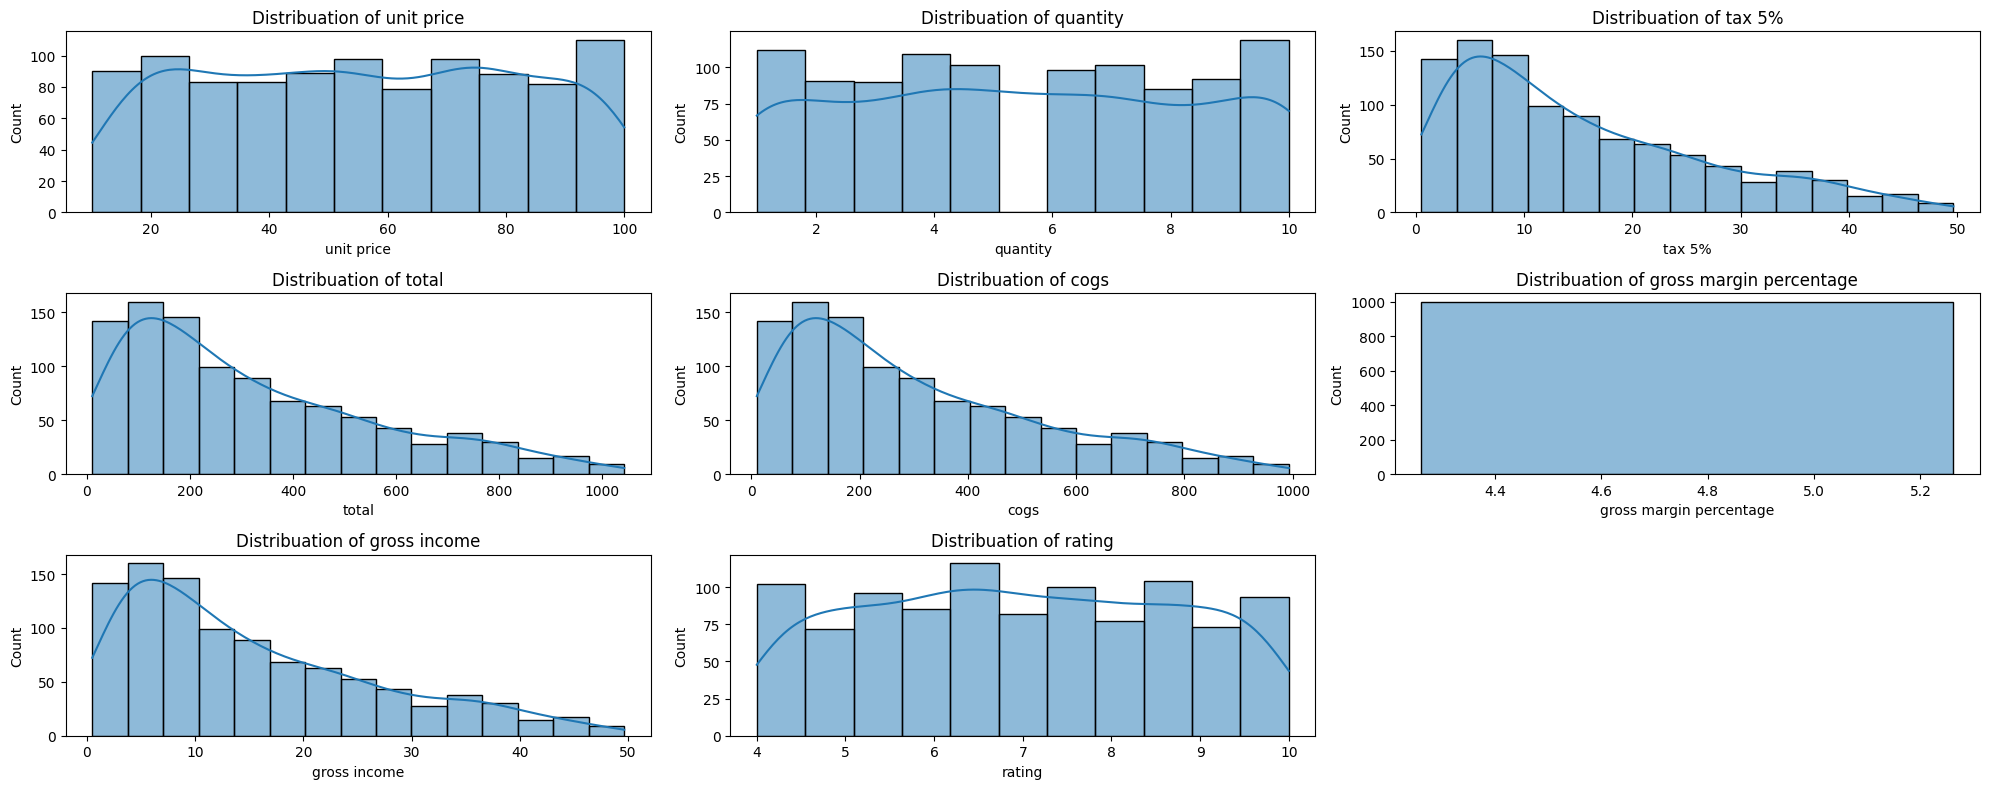

In [135]:
# Analyze distribution of numerical data
# Plot the distribution of numerical values using histograms
n_cols = df.select_dtypes('number')
plt.figure(figsize=(20,8))
for index, columname in enumerate(n_cols.columns):
    plt.subplot(3,3, index + 1)
    sns.histplot(n_cols[columname], kde=True)
    plt.title('Distribuation of ' + columname)
    plt.tight_layout()

In [136]:
# Display descriptive statistics for numerical data
df.select_dtypes('number').describe().T

,count,mean,std,min,25%,50%,75%,max
unit price,"1,000.00",55.67,26.49,10.08,32.88,55.23,77.94,99.96
quantity,"1,000.00",5.51,2.92,1.00,3.00,5.00,8.00,10.00
tax 5%,"1,000.00",15.38,11.71,0.51,5.92,12.09,22.45,49.65
total,"1,000.00",322.97,245.89,10.68,124.42,253.85,471.35,"1,042.65"
cogs,"1,000.00",307.59,234.18,10.17,118.50,241.76,448.91,993.00
gross margin percentage,"1,000.00",4.76,0.00,4.76,4.76,4.76,4.76,4.76
gross income,"1,000.00",15.38,11.71,0.51,5.92,12.09,22.45,49.65
rating,"1,000.00",6.97,1.72,4.00,5.50,7.00,8.50,10.00


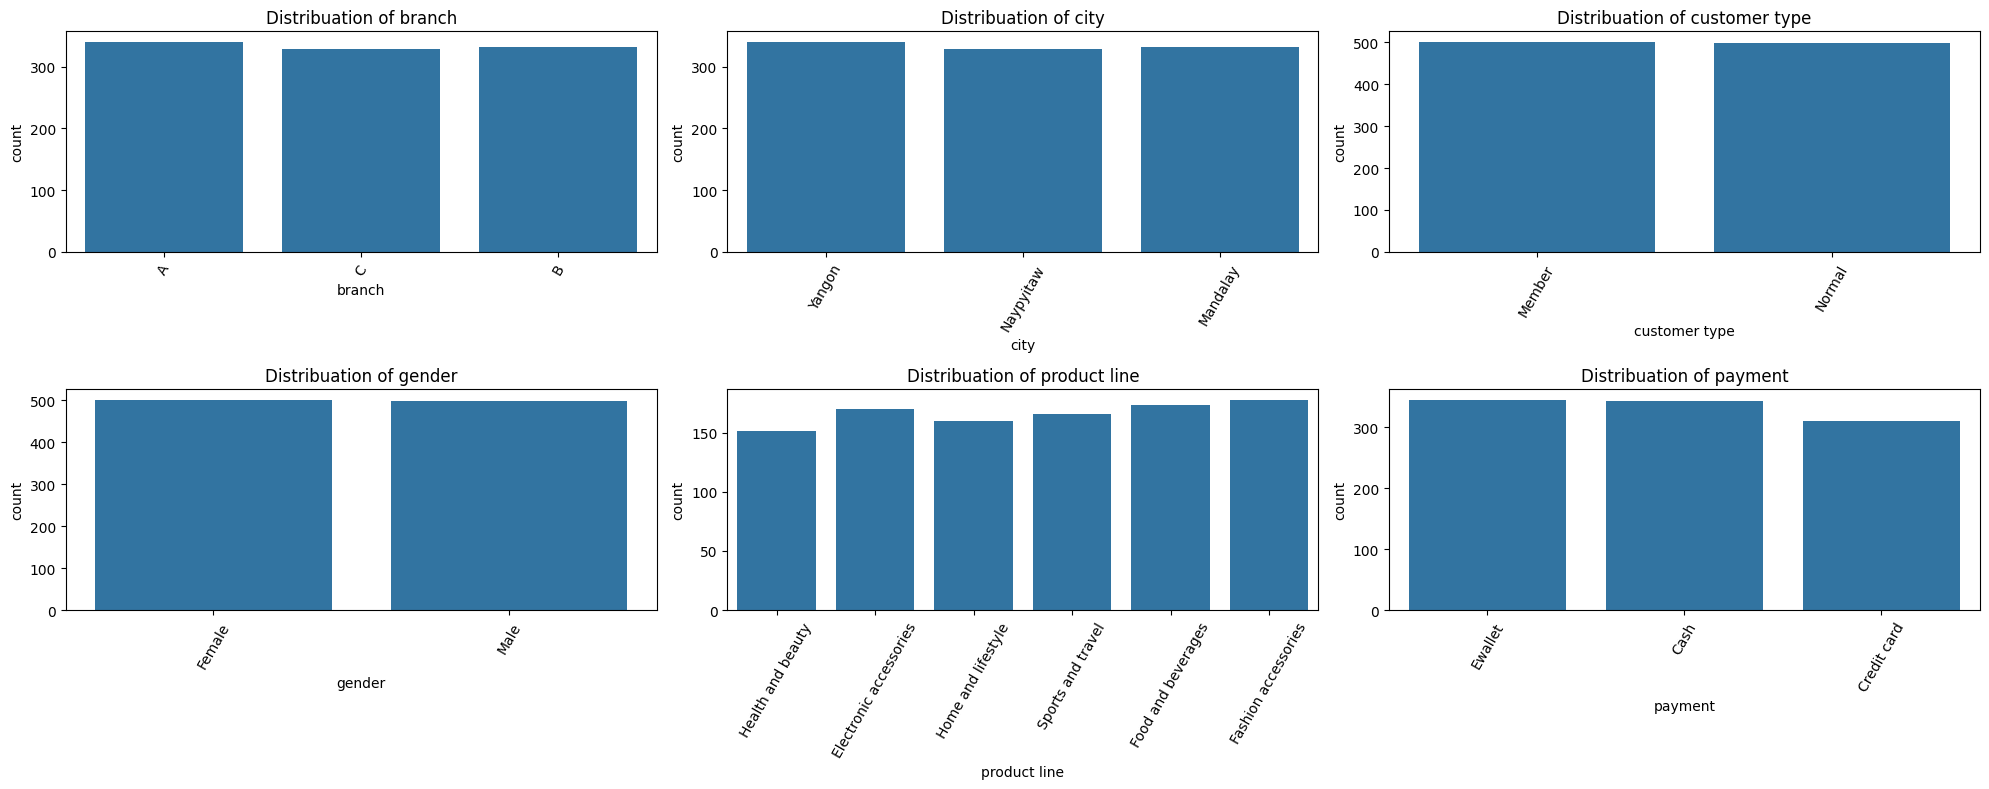

In [137]:
# Analyze distribution of categorical data
# Plot the distribution of values in categorical columns using count plots
o_cols = df.select_dtypes('object')
o_cols = o_cols.iloc[:, 1:]
plt.figure(figsize=(20,8))
for index, columname in enumerate(o_cols.columns):
    plt.subplot(2,3, index + 1)
    sns.countplot(data= o_cols, x= columname)
    plt.title('Distribuation of ' + columname)
    plt.xticks(rotation=60)
    plt.tight_layout()

### Solve Questions

1- How are sales distributed by product type?

In [161]:
# Analyze total sales by product line
# Group total sales by product line and sort in descending order
total_by_product = df.groupby('product line')['total'].sum().sort_values(ascending= False)
table = total_by_product.reset_index()
table.columns = ['product line','total sales']

# Display the final table
print(f"{table['product line'][0]} is the best-selling product line, with {table['total sales'][0]} total sales.")
display(table)

# Plot total sales by product line
fig = px.bar(total_by_product, text_auto=True, title= 'Total by Product', labels= {'product line':'Product Line' ,'value':'Total Sales'})
fig.update_traces(marker_color= 'rgb(158,202,225)', marker_line_color= 'rgb(8, 48, 107)', marker_line_width = 1.5, opacity = 0.6, textposition = 'inside')
fig.show()

Food and beverages is the best-selling product line, with 56144.844 total sales.


,product line,total sales
0,Food and beverages,"56,144.84"
1,Sports and travel,"55,122.83"
2,Electronic accessories,"54,337.53"
3,Fashion accessories,"54,305.89"
4,Home and lifestyle,"53,861.91"
5,Health and beauty,"49,193.74"


2- Is there a difference in spending between members and regular customers?

In [139]:
# Analyze sales by customer type
# Group the dataset by 'customer type' and sum the 'total' sales for each type
total_by_customer_type = df.groupby('customer type')['total'].sum().sort_values(ascending=False)
table = total_by_customer_type.reset_index()
table.columns = ['Customer Type', 'Total sales']

# Calculate the difference and percentage difference between member and normal customers
difference = total_by_customer_type['Member'] - total_by_customer_type['Normal']
percentage_difference = difference / total_by_customer_type['Normal'] * 100

# Display the results and the final table
print(f"Members' spending reached {total_by_customer_type['Member']:.2f} while regular customers' total spending was {total_by_customer_type['Normal']:.2f} The difference is {difference:.2f} which is {percentage_difference:.2f}%")
display(table)

# Plot a bar chart to visualize total sales by customer type
fig = px.bar(total_by_customer_type, text_auto= True, title= 'Total Sales by Customer Type', labels= {'value':'Total Sales'})
fig.update_traces(marker_color= 'rgb(158,202,225)', marker_line_color= 'rgb(8, 48, 107)', marker_line_width = 1.5, opacity = 0.6, textposition = 'inside')
fig.show()


Members' spending reached 164223.44 while regular customers' total spending was 158743.30 The difference is 5480.14 which is 3.45%


,Customer Type,Total sales
0,Member,"164,223.44"
1,Normal,"158,743.30"


3- What are the best selling products by customer gender?

In [140]:
# Analyze total sales by product line and gender
# Group total sales by product line and gender and sort in descending order
total_by_product_and_gender = df.groupby(['product line', 'gender'])['total'].sum().reset_index()
total_by_product_and_gender = total_by_product_and_gender.sort_values(by= ['product line','total'], ascending= [False, False])
total_by_product_and_gender.columns = ['Product', 'Gender', 'Total Sales']

# Display the final table of total sales by product line and gender
display(total_by_product_and_gender)

# Plot a bar chart to visualize total sales by product line and gender
fig = px.bar(total_by_product_and_gender, x= 'Product', y='Total Sales', color='Gender', color_discrete_map={ 'Male': 'rgb(20,20,180)','Female': 'rgb(150,30,50)'}, text_auto=True, title= 'Total Sales by Product and Gender', labels={'x':'Product Line','y': 'Total Sales'})
fig.update_traces(textposition= 'inside')
fig.show()

# Top Selling Product for Women
# Filter the dataset to include only females, sort by total sales in descending order, and get the top product 
most_ordered_by_female = total_by_product_and_gender[total_by_product_and_gender['Gender'] == 'Female'].sort_values(by= 'Total Sales', ascending= False).iloc[0]

# Top Selling Product for men
# Filter the dataset to include only males, sort by total sales in descending order, and get the top product
most_ordered_by_male = total_by_product_and_gender[total_by_product_and_gender['Gender'] == 'Male'].sort_values(by= 'Total Sales', ascending= False).iloc[0]

# show result
# Print the top-selling product for females along with the total sales
print(f"Females most frequently ordered '{most_ordered_by_female['Product']}' generating total sales of {most_ordered_by_female['Total Sales']:.2f}")

# Print the top-selling product for males along with the total sales
print(f"For males, the most ordered product is '{most_ordered_by_male['Product']}' with total sales amounting to {most_ordered_by_male['Total Sales']:.2f}")

,Product,Gender,Total Sales
10,Sports and travel,Female,"28,574.72"
11,Sports and travel,Male,"26,548.11"
8,Home and lifestyle,Female,"30,036.88"
9,Home and lifestyle,Male,"23,825.04"
7,Health and beauty,Male,"30,632.75"
6,Health and beauty,Female,"18,560.99"
4,Food and beverages,Female,"33,170.92"
5,Food and beverages,Male,"22,973.93"
2,Fashion accessories,Female,"30,437.40"
3,Fashion accessories,Male,"23,868.49"


Females most frequently ordered 'Food and beverages' generating total sales of 33170.92
For males, the most ordered product is 'Health and beauty' with total sales amounting to 30632.75


4- What are the peak sales times?

In [141]:
# Extract hours from the 'time' column to create a new 'Hour' column
df['Hour'] = df['time'].dt.hour

# Group total sales by hour and calculate the sum for each hour
total_sales_by_hour = df.groupby('Hour')['total'].sum().reset_index()

# Sort the total sales by hour in descending order
total_sales_by_hour = total_sales_by_hour.sort_values(by='total', ascending=False)

# Display the top 10 hours with the highest sales and print the peak time
print(f"The peak hour is {total_sales_by_hour['Hour'].loc[total_sales_by_hour['total'].idxmax()]} PM with total sales of {total_sales_by_hour['total'].max():.2f}")
display(total_sales_by_hour.head(10))

# Plot a bar chart to visualize total sales by hour
fig = px.bar(total_sales_by_hour, x='Hour', y='total', text_auto= True, title='Sales by Hour',
    labels={'Hour': 'Hour', 'total': 'Total Sales'}
)
fig.update_traces(textposition= 'outside', marker_color= 'rgb(158,202,225)', marker_line_color= 'rgb(8,48,107)')
fig.show()


The peak hour is 19 PM with total sales of 39699.51


,Hour,total
9,19,"39,699.51"
3,13,"34,723.23"
0,10,"31,421.48"
5,15,"31,179.51"
4,14,"30,828.40"
1,11,"30,377.33"
2,12,"26,065.88"
8,18,"26,030.34"
6,16,"25,226.32"
7,17,"24,445.22"


5- What are the most commonly used payment methods? Do they differ by branch or city?

In [142]:
# Count the number of occurrences of each payment method in the 'payment' column
payment_counts = df['payment'].value_counts().reset_index()
# Rename the columns for clarity
payment_counts.columns = ['payment Method','Count']

# Display the payment method counts
display(payment_counts)

# Create and display a pie chart showing the distribution of payment methods
fig = px.pie(data_frame= payment_counts, names= 'payment Method', values= 'Count', title= 'Count of payment method')
fig.show()
# Print the most used payment method and its count
print(f"the most payment method used is {payment_counts['payment Method'].iloc[0]} with total count {payment_counts['Count'].iloc[0]} times")

# Count the number of occurrences of each payment method by city

count_payment_by_city = df.groupby(['city','payment'])['total'].count().reset_index().sort_values('total', ascending= False)

# Rename the columns for clarity
count_payment_by_city.columns = ['City', 'Payment Method', 'Count']

# Display the payment method counts by city
display(count_payment_by_city)

# Print the most used payment method and its count by city
print(f"the most city that use {count_payment_by_city['Payment Method'].iloc[0]} as payment method is {df['city'].max()} with total count {count_payment_by_city['Count'].iloc[0]} times")

# Count the number of occurrences of each payment method by branch
count_payment_by_branch = df.groupby(['branch','payment'])['total'].count().reset_index().sort_values('total', ascending= False)
# Rename the columns for clarity
count_payment_by_branch.columns = ['branch', 'Payment Method', 'Count']
# Display the payment method counts by branch
display(count_payment_by_branch)

# Print the most used payment method and its count by branch
print(f"the most branch that use {count_payment_by_branch['Payment Method'].iloc[0]} as payment method is {df['branch'].max()} with total count {count_payment_by_branch['Count'].iloc[0]} times")

,payment Method,Count
0,Ewallet,345
1,Cash,344
2,Credit card,311


the most payment method used is Ewallet with total count 345 times


,City,Payment Method,Count
8,Yangon,Ewallet,126
3,Naypyitaw,Cash,124
2,Mandalay,Ewallet,113
0,Mandalay,Cash,110
6,Yangon,Cash,110
1,Mandalay,Credit card,109
5,Naypyitaw,Ewallet,106
7,Yangon,Credit card,104
4,Naypyitaw,Credit card,98


the most city that use Ewallet as payment method is Yangon with total count 126 times


,branch,Payment Method,Count
2,A,Ewallet,126
6,C,Cash,124
5,B,Ewallet,113
0,A,Cash,110
3,B,Cash,110
4,B,Credit card,109
8,C,Ewallet,106
1,A,Credit card,104
7,C,Credit card,98


the most branch that use Ewallet as payment method is C with total count 126 times


6- Is there a relationship between customer rating and profit margin?


Text(0, 0.5, 'Rating')

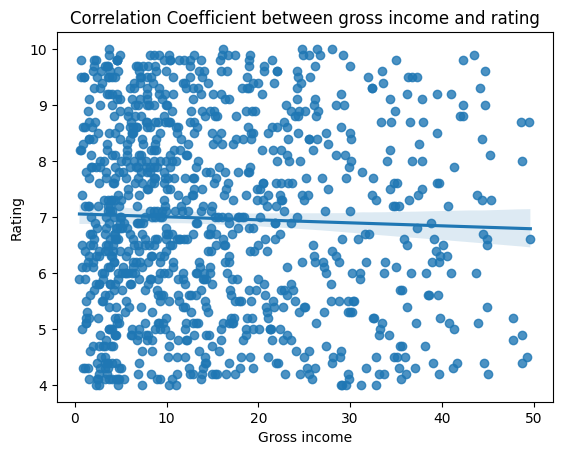

In [143]:
# Select the relevant columns 'gross income' and 'rating' from the dataframe to examine their relationship
corr = df[['gross income','rating']]

# Create a regression plot to visualize the relationship between 'gross income' and 'rating'
sns.regplot(data= corr, x= 'gross income', y= 'rating')
plt.title('Correlation Coefficient between gross income and rating')
plt.xlabel('Gross income')
plt.ylabel('Rating')

the relation is negative and its correlation coefficent is -0.04 which is negative relation


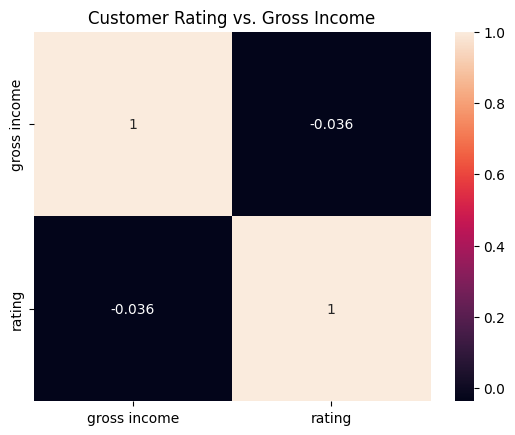

In [144]:
# Compute the correlation matrix for 'gross income' and 'rating'
sns.heatmap(corr.corr(), annot= True)
plt.title('Customer Rating vs. Gross Income')

# Print the correlation coefficient between 'gross income' and 'rating'
# It indicates the strength and direction of the relationship between these two variables
print(f"the relation is negative and its correlation coefficent is {df['gross income'].corr(df['rating']):.2f} which is negative relation")

7- Which branches get the highest rating?

In [145]:
# Group the data by 'branch' and calculate the average 'rating' for each branch
rating_by_branch = df.groupby('branch')['rating'].mean().reset_index()
# Sort the data by 'rating' in descending order to have the highest rating first
rating_by_branch = rating_by_branch.sort_values(by= 'rating', ascending= False)
# Rename the columns for clarity
rating_by_branch.columns = ['Branch', 'Rating']

# Display the dataframe with the ratings by branch
display(rating_by_branch)

# Create a bar plot to visualize the average rating for each branch
fig = px.bar(data_frame= rating_by_branch, x= 'Branch', y= 'Rating', text_auto= True, title= 'Rating by Branch')
fig.show()

# Print the branch with the highest rating and its rating value
print(f"branch {rating_by_branch['Branch'].iloc[0]} has the highest rating whcih is {rating_by_branch['Rating'].max():.2f}")

,Branch,Rating
2,C,7.07
0,A,7.03
1,B,6.82


branch C has the highest rating whcih is 7.07


8- What is the total tax paid?

In [146]:
# Calculate the total sum of the 'tax 5%' column and round it to two decimal places
sum_of_tax = df['tax 5%'].sum().round(2)
print(f"Total taxes paid: {sum_of_tax}")

Total taxes paid: 15379.37


### Bivariate Analysis
1- How many Males and Females in each Branch

2- Branch VS. Total

In [147]:
# Group the data by 'branch' and 'gender', and count the number of occurrences of 'total' for each group
grouping = df.groupby(['branch','gender'], as_index= False)['total'].count()

# Display the grouped data to see the number of males and females in each branch
display(grouping)

# Create a bar plot to visualize the number of males and females in each branch
px.bar(data_frame= grouping, text_auto=True, x= 'gender', y='total', color= 'branch', title= 'Number of Males and Females in each Branch' )

,branch,gender,total
0,A,Female,161
1,A,Male,179
2,B,Female,162
3,B,Male,170
4,C,Female,178
5,C,Male,150


We can notice that the number of men is greater than women except Branch 'C', so it is interesting if we can study further why.

In [148]:
# Select the relevant columns 'branch', 'total', and 'date' from the dataframe for analysis
grouping = df[['branch','total','date']]

# Group the data by 'date' and 'branch' and sum the 'total' values for each group
grouping = grouping.groupby(['date', 'branch'], as_index= False)['total'].sum()
# Pivot the grouped data so that 'date' becomes the index, 'branch' becomes the columns, and 'total' becomes the values
grouping = grouping.pivot(index= 'date', columns= 'branch', values= 'total')
# Create a line plot to visualize the total sums over time for each branch
px.line(data_frame= grouping)



We need to observe the count of invoices, therefore we need to normalize the total to start with 1, to do this we will devide the total of each column by day One. 

Norm = df/df.iloc[0,:]

In [149]:
# Normalize the data by dividing each value by the first row (initial values) of each branch
# This shows the relative change in sales for each branch compared to its initial sales
norm = grouping / grouping.iloc[0,:]

# Display the normalized data to inspect the relative sales movement for each branch
display(norm.head())
# Create a line plot to visualize the sales movement over time for each branch
px.line(data_frame= norm, title= 'The Sales Movement in each Branch')

branch,A,B,C
date,,,
2019-01-01,1.00,1.00,1.00
2019-01-02,0.13,0.76,0.57
2019-01-03,0.40,0.66,0.15
2019-01-04,0.20,0.33,0.75
2019-01-05,0.85,0.32,1.22


it's clear that the branch 'A' has less sales movement than the others, we need more data to investigate why.

In [150]:
# Group the data by 'branch' and calculate the total sales ('total') for each branch
grouping = df.groupby('branch')['total'].sum()

# Reset the index and sort the grouped data by 'total' in descending order
table = grouping.reset_index().sort_values(by= 'total', ascending= False)
display(table)

# Print the branch with the highest total sales
print(f'Branch {grouping.idxmax()} is the most profitable, with total sales amounting to {grouping.max():.2f}')

# Create a pie chart to visualize the total sales amounts across all branches
px.pie(data_frame= grouping, names= grouping.index, values= 'total', title= 'Total Amount of all invoices in each branch')

,branch,total
2,C,"110,568.71"
0,A,"106,200.37"
1,B,"106,197.67"


Branch C is the most profitable, with total sales amounting to 110568.71


### MultiVariate Analysis
* Rating of Males/Females in each Branch in each Month

In [151]:
# Extract the month from the 'date' column
df['month'] = df['date'].dt.month

# Select relevant columns 'branch', 'gender', 'rating', and 'month' from the dataframe for further analysis
grouping = df[['branch','gender','rating', 'month']]

In [152]:
# Create a new column 'gender_month' by combining 'gender' and 'month' columns
grouping['gender_month'] = grouping['gender'] + ' - ' + grouping['month'].astype(str)

# Group the data by 'branch' and 'gender_month', and calculate the average 'rating' for each group
grouping = grouping.groupby(['branch','gender_month'], as_index= False)['rating'].mean()
grouping

C:\Users\Azhaa\AppData\Local\Temp\ipykernel_8552\3202964635.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,branch,gender_month,rating
0,A,Female - 1,7.06
1,A,Female - 2,6.64
2,A,Female - 3,6.81
3,A,Male - 1,7.09
4,A,Male - 2,7.39
5,A,Male - 3,7.16
6,B,Female - 1,6.92
7,B,Female - 2,6.97
8,B,Female - 3,6.73
9,B,Male - 1,6.67


In [153]:
# Create a scatter plot to visualize the average ratings for each branch and gender-month combination
px.scatter(data_frame= grouping, x= 'branch', y= 'rating', color= 'gender_month')

In [162]:
print("\nSummary:")
print(f"- The branch with the highest total sales is Branch C.")
print(f"- The product line with the highest total sales is {table['product line'][0]}.")
print(f"- Members spend more than regular customers by {percentage_difference:.2f}%, indicating a stronger loyalty effect.")
print(f"- Females most frequently ordered '{most_ordered_by_female['Product']}' generating total sales of {most_ordered_by_female['Total Sales']:.2f}")
print(f"- For males, the most ordered product is '{most_ordered_by_male['Product']}' with total sales amounting to {most_ordered_by_male['Total Sales']:.2f}")
print(f"- The peak hour is {total_sales_by_hour['Hour'].loc[total_sales_by_hour['total'].idxmax()]} PM with total sales of {total_sales_by_hour['total'].max():.2f}")
print(f"- the most payment method used is {payment_counts['payment Method'].iloc[0]} with total count {payment_counts['Count'].iloc[0]} times and {df['city'].max()} is the city that used this method the most. As for the branches, it is Branch {df['branch'].max()}")
print(f"- branch {rating_by_branch['Branch'].iloc[0]} has the highest rating whcih is {rating_by_branch['Rating'].max():.2f}")
print(f"- branch 'A' has less sales movement than the others, Branch C has the highest.")


Summary:
- The branch with the highest total sales is Branch C.
- The product line with the highest total sales is Food and beverages.
- Members spend more than regular customers by 3.45%, indicating a stronger loyalty effect.
- Females most frequently ordered 'Food and beverages' generating total sales of 33170.92
- For males, the most ordered product is 'Health and beauty' with total sales amounting to 30632.75
- The peak hour is 19 PM with total sales of 39699.51
- the most payment method used is Ewallet with total count 345 times and Yangon is the city that used this method the most. As for the branches, it is Branch C
- branch C has the highest rating whcih is 7.07
- branch 'A' has less sales movement than the others, Branch C has the highest.
